# Multi-Class Random Forest Classification

Uses optimal hyperparameters:
- n_estimators: 200
- min_samples_leaf: 1
- bag_fraction: 0.3
- max_depth (maxNodes): 10

## Six-class schema notice

This notebook now uses the canonical 19-band, six-class pipeline. Existing embedded figures/output were produced before Agriculture label 5 and are historical until all cells are rerun.


In [1]:
import os
import ee
import geemap
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()
ee.Initialize(project=os.getenv('EE_PROJECT_ID'))

# os.makedirs('../../assets', exist_ok=True)

In [ ]:
# Canonical six-class / 19-band schema shared with backend and evaluation runner.
from backend.config import BANDS, FEATURE_COLLECTIONS, LAND_COVER_CLASSES, SEASONS
from backend.gee_classifier import build_sentinel_composite, merge_feature_collections, sample_training_points

PRE_AGRICULTURE_OUTPUTS = True  # Embedded outputs below predate label 5 until this notebook is rerun.
season = SEASONS["summer"]  # defined here so the composite cell can read it.
bands = BANDS
class_names = [LAND_COVER_CLASSES[i]["name"] for i in LAND_COVER_CLASSES]
class_palette = [LAND_COVER_CLASSES[i]['color'].lstrip('#') for i in LAND_COVER_CLASSES]
legend_dict = {f"{info['name']} ({label})": info['color'].lstrip('#')
               for label, info in LAND_COVER_CLASSES.items()}


In [2]:
campus_geojson = {
    "type": "Polygon",
    "coordinates": [
        [
            [80.01710357666015, 23.173962177472703],
            [80.03259601593017, 23.165361215115187],
            [80.03654422760009, 23.172502420044232],
            [80.026802444458,   23.181694681000845],
            [80.01542987823485, 23.176960548201308],
        ]
    ]
}
campus = ee.Geometry(campus_geojson)

def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud  = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return image.updateMask(mask).divide(10000)

dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterDate(season['start'], season['end'])
      .filterBounds(campus)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
      .map(mask_s2_clouds)
)
composite = dataset.median().clip(campus)

ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndbi = composite.normalizedDifference(['B11', 'B8']).rename('NDBI')
savi = composite.expression(
    '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
    {'NIR': composite.select('B8'), 'RED': composite.select('B4')}
).rename('SAVI')

composite = composite.addBands([ndvi, ndwi, ndbi, savi])
bands = BANDS
# Canonical feature composite override: exact Summer dates and all retained 19 bands.
season = SEASONS["summer"]
composite = build_sentinel_composite(campus, season["start"], season["end"])
bands = BANDS


In [ ]:
# Load every configured current asset; this includes repositioned Jabalpur water
# (1,000 points), Barren Land, MP sand, and Agriculture label 5. Legacy water_points (100)
# is intentionally never referenced.
class_names = [LAND_COVER_CLASSES[i]["name"] for i in LAND_COVER_CLASSES]
class_collections = [ee.FeatureCollection(path) for path in FEATURE_COLLECTIONS.values()]
all_points = merge_feature_collections(FEATURE_COLLECTIONS.values())

def assign_block(feature):
    coords = feature.geometry().coordinates()
    bx = ee.Number(coords.get(0)).multiply(10).floor()
    by = ee.Number(coords.get(1)).multiply(10).floor()
    return feature.set("blk", bx.multiply(31).add(by.multiply(17)).mod(10))

blocked_points = all_points.map(assign_block)
season = SEASONS["summer"]
train_set = sample_training_points(
    blocked_points.filter(ee.Filter.lt("blk", 7)),
    start_date=season["start"], end_date=season["end"],
)
test_set = sample_training_points(
    blocked_points.filter(ee.Filter.gte("blk", 7)),
    start_date=season["start"], end_date=season["end"],
)
training = train_set.merge(test_set)

print("--- Canonical point assets ---")
for key, collection in zip(FEATURE_COLLECTIONS, class_collections):
    print(key, collection.size().getInfo())
print("Train Set Size:", train_set.size().getInfo())
print("Test Set Size:", test_set.size().getInfo())


Overall Accuracy: 0.8795180722891566
Kappa Coefficient: 0.8329718489367888

--- Class-wise Accuracy ---
Forest: 0.9114
Water: 0.9655
Buildings: 0.8276
Soil: 0.8554



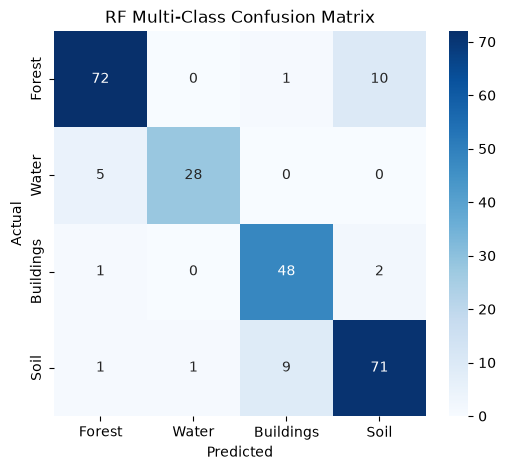

In [4]:
rf_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=200,
    minLeafPopulation=1,
    bagFraction=0.3,
    maxNodes=10
).train(
    features=train_set,
    classProperty='label',
    inputProperties=bands
)

test_classified = test_set.classify(rf_classifier)
confusion_matrix = test_classified.errorMatrix('label', 'classification')

print('Overall Accuracy:', confusion_matrix.accuracy().getInfo())
print('Kappa Coefficient:', confusion_matrix.kappa().getInfo())

print('\n--- Class-wise Accuracy ---')
consumers_acc = confusion_matrix.consumersAccuracy().getInfo()

for i, name in enumerate(class_names):
    # Safely access the 0th row, then the i-th column
    if i < len(consumers_acc[0]):
        acc = consumers_acc[0][i] if consumers_acc[0][i] is not None else 0.0
    else:
        acc = 0.0
        
    print(f'{name}: {acc:.4f}')

print()

cm_array = confusion_matrix.array().getInfo()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RF Multi-Class Confusion Matrix')
plt.savefig('../../doc/assets/multi_rf_cm.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
classified = composite.select(bands).classify(rf_classifier)
classified_smooth = classified.focalMode(radius=1, kernelType='square', units='pixels')

class_palette = [LAND_COVER_CLASSES[i]['color'].lstrip('#') for i in LAND_COVER_CLASSES]

Map = geemap.Map(center=[23.174, 80.026], zoom=15)
Map.addLayer(composite, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'RGB Composite')
Map.addLayer(classified_smooth, {'min': 0, 'max': len(LAND_COVER_CLASSES) - 1, 'palette': class_palette}, 'RF Classification')

legend_dict = {f"{info['name']} ({label})": info['color'].lstrip('#') for label, info in LAND_COVER_CLASSES.items()}
Map.add_legend(title='Land Cover', legend_dict=legend_dict)
Map.addLayer(campus, {}, 'Campus Boundary')
Map

Map(center=[23.174, 80.026], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [6]:
area_image = ee.Image.pixelArea().addBands(classified_smooth)
areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=campus,
    scale=10,
    maxPixels=1e10
)

area_data = areas.getInfo()['groups']
print("--- Class Areas (Hectares) ---")
for entry in area_data:
    ha = entry['sum'] / 10000
    print(f"{class_names[entry['class']]}: {ha:.2f} ha")

--- Class Areas (Hectares) ---
Forest: 77.10 ha
Water: 6.40 ha
Buildings: 17.40 ha
Soil: 98.16 ha
